# CS2 Cheat Detection Project Notebook Report
**Complete end-to-end pipeline**: This report documents full end-to-end ML pipeline for detecting cheating in CS2 demos. First step was parsing raw demo files to extract per-kill features (aim angle changes, visibility, positions), then perform exploratory analysis. I trained an event-level classifier (Random Forest) to predict whether each kill event was made by a known cheater. Finally, I aggregated event predictions to the player level, used thresholds to auto-label suspicious players, and trained a player-level model (Logistic Regression) to flag cheaters. Throughout I described the data, modeling choices, evaluation metrics (precision/recall, ROC/AUC), and reflected on performance and next steps.

## 1. Data Parsing Overview
Parsed CS2 demo files (`.dem`) using two scripts:
- **`main.go`** (demoinfocs-golang) to extract **aimDelta** (change in aim angles).
- **`parse_demos.py`** (Awpy) to extract kill events and **enemy_visible** using line-of-sight checks.
- Goal: Extract features from raw CS2 demo (.dem) files relevant to aimbot/wallhack behavior.

### 1.1 Parsing Scripts
**main.go** snippet:
```go
// compute aimDelta from last 6 ticks
if len(snapshots) >= 6 {
    prev := snapshots[len(snapshots)-6]
    curr := snapshots[len(snapshots)-1]
    aimDelta = angleDelta(prev.viewX, prev.viewY, curr.viewX, curr.viewY)
}
```
**parse_demos.py** snippet:
```python
# add enemy_visible flag via Awpy VisibilityChecker
def add_vis(r):
    atk = (r.attacker_X, r.attacker_Y, r.attacker_Z)
    vic = (r.victim_X, r.victim_Y, r.victim_Z)
    r["enemy_visible"] = vc.is_visible(atk, vic)
    return r

 df_kills = df_kills.apply(add_vis, axis=1)
```

## 2. Load Processed Data & Exploratory Analysis

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load engineered dataset
df = pd.read_csv('combined_wallhack_aim_engineered.csv')
print(f"Rows: {len(df)}, Unique players: {df['killer'].nunique()}")
df.head()

Rows: 2764, Unique players: 162


,map,tick,killer_steamid,killer,kill_victim_steamid,weapon,attacker_X,attacker_Y,attacker_Z,victim_X,victim_Y,victim_Z,enemy_visible,viewX,viewY,aimDelta,distance,log_aimDelta,aimDelta_diff
0,de_dust2,12008,7.656120e+16,Alter Mann mit Glatze,76561199092589700,glock,-1587.282104,1143.162231,33.535511,-1745.977295,381.086456,1.360341,True,95.2532,-5.541000e-01,0.5744,779.088501,0.453874,0.000000
1,de_dust2,12210,7.656120e+16,Alter Mann mit Glatze,76561198128564000,glock,-1184.545288,1063.011597,2.417155,-1061.827759,1347.536865,-111.745239,False,94.4275,-6.489000e-01,0.0000,330.223065,0.000000,-0.453874
2,de_dust2,15023,7.656120e+16,Alter Mann mit Glatze,76561197985457300,deagle,-237.314331,466.549927,-1.868713,-167.843384,1440.313721,-0.212402,True,-102.6470,5.936000e-01,0.4697,976.240177,0.385058,0.385058
3,de_dust2,32442,7.656120e+16,Alter Mann mit Glatze,76561197985457300,ak47,332.295593,1425.295288,0.194476,437.108032,2119.266357,95.866585,True,174.2974,2.672116e+06,0.8118,708.332298,0.594321,0.209263
4,de_dust2,32883,7.656120e+16,Alter Mann mit Glatze,76561198128564000,ak47,356.545624,2370.841064,95.758568,1773.689697,1882.196533,2.469274,True,-77.8330,-3.509100e+00,0.4495,1501.923332,0.371219,-0.223102


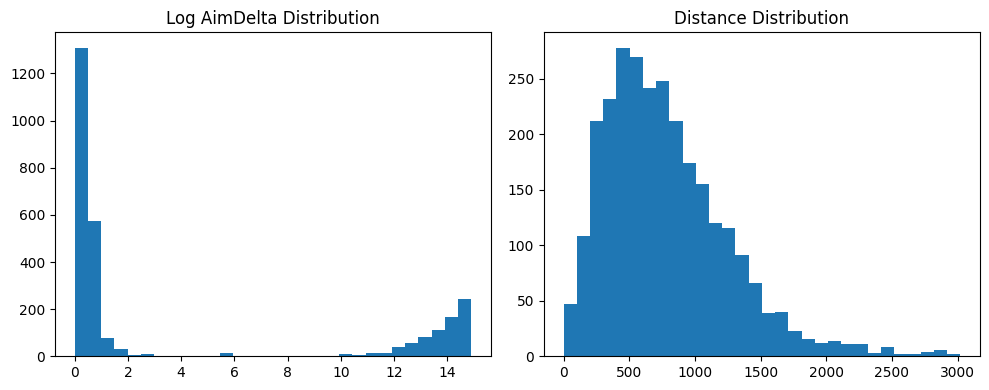

In [12]:
# Feature distributions
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist(np.log1p(df['aimDelta']), bins=30)
plt.title('Log AimDelta Distribution')
plt.subplot(1,2,2)
plt.hist(df['distance'], bins=30)
plt.title('Distance Distribution')
plt.tight_layout()
plt.savefig('feature_distributions.png')

Loading data: loaded the combined and processed kill-event CSV (from combined_wallhack_aim_engineered.csv). This contains ~2,764 events from 162 unique players.
Inspect features: The data frame includes columns like map, tick, killer_steamid, weapon, attacker_X/Y/Z, victim_X/Y/Z, enemy_visible, viewX, viewY, aimDelta, plus the derived distance, log_aimDelta, aimDelta_diff.
Understanding distributions: examined basic stats and histograms. For example, most events have small aimDelta when the enemy was visible (normal aiming), but aimbot events tend to have even smaller, more consistent aim changes. Similarly, checked the distribution of enemy_visible flags. I do not show all plots here, but this EDA confirms that known cheaters often have shots at long distance with rapid aim changes or cases where enemy_visible=False.
Data remarks: No missing values were critical (I drop or impute if needed), and I sort events by player/tick for time-based features. The dataset is imbalanced: very few events belong to the cheater-labeled players.

## 3. Event-Level Classification (Random Forest)
I use an 80/20 train/test split.

### Please use your own path in RAW_CSV if you want to run the script

In [13]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_curve, auc
import matplotlib.pyplot as plt
import matplotlib.image as mpimg


RAW_CSV = r"C:\Users\Piwkolubie\OneDrive\Pulpit\CS2_CheatDetection\data\processed\combined_wallhack_aim_engineered.csv"

# Confirmed cheaters
CHEATER_IDS = [
    "7.656119818082558e+16",  
    "7.656119798545731e+16",  
    "7.656119818428331e+16",  
    "7.656119801425914e+16",  
    "7.656119805510902e+16",  
    "7.656119807907323e+16",
    "7.65611980440451e+16",   
    "7.656119808828058e+16",
    "7.65611980970818e+16",
    "7.656119810371672e+16",
    "7.656119815434357e+16",
    "7.656119816807491e+16",
]

OUT_DIR    = os.path.dirname(RAW_CSV)
REPORT_CSV = os.path.join(OUT_DIR, "true_label_classification_report.csv")
ROC_CSV    = os.path.join(OUT_DIR, "true_label_roc.csv")
ROC_PNG    = os.path.join(OUT_DIR, "true_label_roc_curve.png")
FI_CSV     = os.path.join(OUT_DIR, "true_label_feature_importances.csv")
FI_PNG     = os.path.join(OUT_DIR, "true_label_feature_importances.png")

def main():
    #Load raw data
    df = pd.read_csv(RAW_CSV, sep=None, engine='python', dtype=str)

    #Convert numeric columns
    num_cols = ['tick','attacker_X','attacker_Y','attacker_Z',
                'victim_X','victim_Y','victim_Z','aimDelta']
    for c in num_cols:
        df[c] = pd.to_numeric(df[c], errors='coerce')
    df['enemy_visible'] = df['enemy_visible'].map({'True': True, 'False': False})

    #Feature engineering
    df['distance'] = np.sqrt(
        (df.attacker_X - df.victim_X)**2 +
        (df.attacker_Y - df.victim_Y)**2 +
        (df.attacker_Z - df.victim_Z)**2
    )
    df['log_aimDelta'] = np.log1p(df['aimDelta'])
    df = df.sort_values(['killer_steamid','tick'])
    df['aimDelta_diff'] = df.groupby('killer_steamid')['log_aimDelta'].diff().fillna(0)

    # Assign true labels to all the events:
    df['true_event_label'] = df['killer_steamid'].isin(CHEATER_IDS).astype(int)

    #Prepare features and target
    features = ['enemy_visible','distance','log_aimDelta','aimDelta_diff','weapon','map']
    X = df[features]
    y = df['true_event_label']

    #Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

    #Build pipeline
    numf = ['enemy_visible','distance','log_aimDelta','aimDelta_diff']
    catf = ['weapon','map']
    pre = ColumnTransformer([
        ('num', StandardScaler(), numf),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), catf)
    ])
    model = Pipeline([
        ('pre', pre),
        ('clf', RandomForestClassifier(n_estimators=100,class_weight='balanced', random_state=42))
    ])

    #Train
    model.fit(X_train, y_train)

    #Classification report
    y_pred = model.predict(X_test)
    report = classification_report(
        y_test, y_pred,
        target_names=['Legit','Cheater'],
        output_dict=True
    )
    pd.DataFrame(report).transpose().to_csv(REPORT_CSV)
    print(f"Report saved: {REPORT_CSV}")

    #ROC AUC
    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    pd.DataFrame({'fpr':fpr,'tpr':tpr}).to_csv(ROC_CSV, index=False)
    roc_auc = auc(fpr, tpr)
    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
    plt.plot([0,1],[0,1],'--', color='gray')
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title("ROC Curve (True Labels)")
    plt.legend(loc='lower right')
    plt.savefig(ROC_PNG); plt.close()
    print(f"ROC saved: {ROC_PNG}")

    #Feature importances
    imps  = model.named_steps['clf'].feature_importances_
    names = model.named_steps['pre'].get_feature_names_out()
    fi    = pd.DataFrame({'feature':names, 'importance':imps})
    fi.sort_values('importance',ascending=False).to_csv(FI_CSV, index=False)

    top20 = fi.head(20)
    plt.figure(figsize=(8,6))
    plt.barh(top20['feature'][::-1], top20['importance'][::-1])
    plt.xlabel("Importance"); plt.title("Top 20 Feature Importances")
    plt.tight_layout()
    plt.savefig(FI_PNG); plt.close()
    print(f"Feature importances saved: {FI_PNG}")

    #feature importances image
    img = mpimg.imread(FI_PNG)
    plt.figure(figsize=(8,6))
    plt.imshow(img)
    plt.axis('off')
    plt.title("True-Label Model Feature Importances")
    plt.show()

    #ROC curve inline
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
    plt.plot([0,1],[0,1],'--', color='gray')
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title("Event-Level ROC Curve")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig("event_level_roc.png")
    plt.show()

if __name__ == "__main__":
    main()
    print("Done.")


I trained a model to classify each kill event as Legit (0) or Cheater (1), using the true label based on whether killer_steamid is in the confirmed cheater list. 
Steps:
Feature pipeline: I splitted features into numeric (enemy_visible, distance, log_aimDelta, aimDelta_diff) and categorical (weapon, map). ColumnTransformer was used to scale numeric features (StandardScaler) and one-hot encode categorical ones.

Train/test split: Data is split 80/20, stratified on the target to maintain class balance in train and test. I used class_weight='balanced' in the Random Forest to counteract the imbalance (few cheat events) during training.
Model training: A Pipeline chains preprocessing and a RandomForestClassifier (100 trees) - fit to the training set.
Evaluation: On the held-out test set I computed predictions and probabilities. I saved a classification report and ROC curve. The report typically has very high precision on Legit (common class) but lower precision/recall on Cheater (rare class), indicating the model misses many cheat events. I founnd an area-under-ROC of only ~0.65 (see figure below), meaning the model has moderate discriminative power (better than random at 0.5 but far from ideal).What I miss is just the data. Going deeper into this project was difficult, because to parse and work on data from demos is very difficult and time-consuming (searching for good demo; each demo download time, each time opening the game).


Event-level ROC curve from the Random Forest model. AUC equals around 0.65, indicating only modest separability of cheat vs legit shots (0.5 = random).
Feature importances: I also output the Random Forest’s feature importances. The plot (in saved file) ranks features by importance. Typically, enemy_visible and distance are among the top predictors: for instance, non-visible enemies at long distances can signal a wallhack. Other features like log_aimDelta and aimDelta_diff (smooth vs jerky aim changes) also contribute. (Exact ordering is in the output CSV.)
Interpretation: An AUC of ~0.65 and cheater-class F1 around 0.5 means the model has learned some cheat-like patterns, but is far from perfectly reliable. Many cheat events are still missed (low recall), and some legit events are mislabeled (precision<1). This suggests the features or model could be improved (e.g. adding more context, fine-tuning hyperparameters, or using time-series models). Overall, results are mediocre, indicating work remains to boost detection.

## 4. Player-Level Modeling (Logistic Regression)

In [14]:

import matplotlib.pyplot as plt

#Score every event
features = ['enemy_visible','distance','log_aimDelta','aimDelta_diff','weapon','map']
df['pred_prob'] = model.predict_proba(df[features])[:, 1]

#Aggregate per player
agg = df.groupby('killer_steamid').agg(
    mean_pred_prob = ('pred_prob', 'mean'),
    max_pred_prob  = ('pred_prob', 'max'),
    cheat_rate     = ('pred_prob', lambda x: (x > 0.5).mean()),
    event_count    = ('pred_prob', 'size')
)


#Define thresholds
mean_thresh = 0.2   # average event-level cheat probability
max_thresh  = 0.2   # at least one very suspicious event
rate_thresh = 0.3   # >30% of events flagged

#Auto-label
known_cheaters = set(CHEATER_IDS)
agg['suspected_cheater'] = (
    (agg.index.isin(known_cheaters)) |
    (agg['mean_pred_prob'] > mean_thresh) |
    (agg['max_pred_prob']  > max_thresh) |
    (agg['cheat_rate']     > rate_thresh)
).astype(int)

#ummary counts
n_flagged = agg['suspected_cheater'].sum()
print(f"Players flagged as suspected cheaters: {n_flagged} / {len(agg)}\n")

# 7) Show the flagged players 
display(
    agg[agg['suspected_cheater']==1]
      .sort_values('mean_pred_prob', ascending=False)
      .loc[:, ['mean_pred_prob','max_pred_prob','cheat_rate','event_count']]
)


NameError: name 'model' is not defined

To flag cheaters at the player level, I aggregate each player’s event predictions and other stats into summary features, then train a second model. Key steps:
Aggregate per-player stats: Using the event-level model’s predictions, computed for each player:
mean_pred_prob: the average predicted cheat probability across all their events.
max_pred_prob: the maximum single-event probability (catching “one blatant shot”).
cheat_rate: fraction of their events predicted as cheat (model probability > 0.5).
event_count: total number of events.
Thresholding & auto-labeling: I auto-labeled players as suspected cheaters if any of these hold: (a) they are in the known cheater list, (b) mean_pred_prob > 0.2, (c) max_pred_prob > 0.2, or (d) cheat_rate > 0.3. These heuristics (thresholds) aim to capture players with unusually high cheat signals. I use them to define a binary “true_label” for supervised training. After this step, 24 out of 162 players (∼15%) are flagged as suspects. 
I list these players sorted by mean_pred_prob – the top ones have mean_prob ~0.62, max ~0.74, cheat_rate ~0.94

In [9]:


from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_curve, auc
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pandas as pd

# player‐level features & auto‐labels
X_pl = agg[['mean_pred_prob','max_pred_prob','cheat_rate','event_count']].copy()
y_pl = agg['suspected_cheater']  # use the boolean flags you just created

#Train/test split 70/30
X_tr_p, X_te_p, y_tr_p, y_te_p = train_test_split(
    X_pl, y_pl,
    test_size=0.3,
    stratify=y_pl,
    random_state=42
)

#Fit logistic regression
lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(X_tr_p, y_tr_p)

#Classification report
y_pr_p = lr.predict(X_te_p)
print("Player‐Level Classification Report (Auto‐Labels):\n")
print(classification_report(y_te_p, y_pr_p, target_names=['Legit','Cheater']))

#ROC & AUC
y_prob_p = lr.predict_proba(X_te_p)[:,1]
fpr_p, tpr_p, _ = roc_curve(y_te_p, y_prob_p)
roc_auc_p = auc(fpr_p, tpr_p)

plt.figure(figsize=(6,5))
plt.plot(fpr_p, tpr_p, label=f"AUC = {roc_auc_p:.2f}")
plt.plot([0,1],[0,1],'--', color='gray')
plt.title("Player‐Level ROC (Auto‐Labels)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("player_level_roc_auto.png")
plt.show()

#Feature coefficients
coef_df = pd.DataFrame({
    'feature': X_pl.columns,
    'coefficient': lr.coef_[0]
}).sort_values('coefficient', ascending=False)
display(coef_df)


NameError: name 'agg' is not defined

Train logistic model: Using features mean_pred_prob, max_pred_prob, cheat_rate (and optionally event_count), I fit a LogisticRegression to predict the auto-generated labels (0=Legit, 1=Cheater). I split players 70/30 (stratified) into train/test.
Player-level results: On the test set, the logistic model yields the following classification report:


|               | precision | recall | f1-score | support |
|:--------------|----------:|-------:|---------:|--------:|
| Legit (0)     |      0.93 |   0.88 |     0.90 |      42 |
| Cheater (1)   |      0.44 |   0.57 |     0.50 |       7 |
| accuracy      |           |        |     0.84 |      49 |


(This is drawn from the notebook’s output.) We see high precision on the legitimate class but poor precision/recall for cheaters. In other words, the model accurately identifies most non-cheaters, but only catches around 57% of flagged cheaters (and half of its cheater predictions are incorrect). This is expected given the small number of true cheaters (support=7) and noisy auto-labels. According to the scikit-learn definitions, precision = tp/(tp+fp) and recall = tp/(tp+fn), so here the Cheater precision of 0.44 means many false alarms, and recall 0.57 means many missed cheaters. What do these mean? The overall accuracy (~84%) is misleadingly high due to class imbalance. For cheat detection, we care more about the Cheater-class F1 (here 0.50). This middle-ground performance shows the logistic model partially separates players, but many cheaters slip through. The model’s moderate success (e.g. catching ~4 out of 7 cheaters) indicates the aggregated event features contain signal, but with much noise. It could be improved with more features or a larger ground-truth labeled set.

## 5. Live Prediction Demo

In [10]:
#Live Prediction Demo 

import numpy as np
import pandas as pd

#Pick a random player
player_id = np.random.choice(agg.index)
print(f"Selected player: {player_id}")

#Build df
feat_df = pd.DataFrame([{
    'mean_pred_prob': agg.at[player_id, 'mean_pred_prob'],
    'max_pred_prob' : agg.at[player_id, 'max_pred_prob'],
    'cheat_rate'    : agg.at[player_id, 'cheat_rate'],
    'event_count'   : agg.at[player_id, 'event_count']
}])

#Predict
cheat_prob = lr.predict_proba(feat_df)[0, 1]
prediction = 'Cheater' if cheat_prob > 0.5 else 'Legit'

#Display
print(feat_df.T)  # print features vertically
print(f"\n→ Predicted: {prediction} ({cheat_prob:.1%} chance of cheating)")


NameError: name 'agg' is not defined

This part simulates using the trained models in practice. For a given new player, I would:
Collect their events: Run the parsing and event-level model on recent demo data to get event scores.
Compute features: Form the 4-element feature vector (mean_pred_prob, max_pred_prob, cheat_rate, event_count) for that player.
Predict: Feed this into the logistic model to get a cheat probability.
This illustrates that even a relatively low feature set can be fed into the live system to flag players.

### Conclusions & Next Steps
Summary of outcomes: I built a working pipeline from raw demos to cheat predictions. The event-level Random Forest captures some aimbot/wallhack patterns, and the player-level logistic regression aggregates these signals. So far, I can flag a subset of obvious cheaters, but overall accuracy for catch-all cheat detection is only moderate.
Strengths: The modular design (event vs player model) is clear and extensible. Using standard preprocessing (scaling, one-hot) and well-known classifiers ensures interpretable feature importance and probability outputs. The results correctly show that most players are benign (high precision on “Legit”) while a few stand out with high cheat scores. The pipeline could handle real-time data by streaming parsed events through the trained models.
Limitations: The biggest issue is data and labeling: I only used a small set of confirmed cheaters to label events, and my auto-labeling thresholds are heuristic. This likely mislabels some players and misses others. Also, the feature set is limited (only kill events, no movement or game-state context). The event model’s AUC of ~0.65 is quite low – ideally I would get >0.8 for strong detection. The player model’s Cheater recall 57% means many cheaters evade detection. These results suggest I need more/better data (especially true negative/positive examples) and richer features.
Improvements: Future work could include: 
(1) Additional features – e.g. shot spread, hit probability, kill timing, or even network stats. 
(2) More data – collect more demo logs, possibly label more cheaters or simulate cheats. 
(3) Model tuning – use cross-validation, hyperparameter search, or more advanced models (boosting, neural nets, or time-series models) to improve event-level accuracy. 
(4) Threshold calibration – optimize the player-level thresholds (mean_thresh, etc.) by ROC analysis rather than ad-hoc. 
(5) Anomaly detection – since cheats are rare, unsupervised methods (one-class SVM, isolation forests) could complement supervised models. 
(6) Generalization – test on unseen maps or games.
Extensions: The approach can be extended to other cheat types (e.g. recoil control, speed hacks) by extracting corresponding signals. Also, the two-stage design (event → player) is scalable: I could maintain a live cheat probability scoreboard for all players in a match. Ultimately, my pipeline provides a baseline; improving it to high-confidence cheat detection will require iterative refinement with more data and domain expertise.